In [27]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
from models import create_linear_model
from sklearn.metrics import mean_squared_error

In [28]:
df = pd.read_csv('../data/processed/AAWW_processed.csv')

In [35]:
# 🧹 3. Prepare features (X) and target (y)
# Use simple technical indicators: 5-day MA, 20-day MA, RSI-14
X = df[['MA_5d', 'MA_20d', 'RSI_14d']].dropna()
y = df['Close'].shift(-1).dropna()

# Align shapes (drop last row in X)
X = X.iloc[:-1]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3571, 3)
Target shape: (3571,)


In [36]:
# 🧪 4. Split into train/test sets
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [37]:
# 🔥 5. Train a simple Linear Regression model
model = create_linear_model(model_type='linear')
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [39]:
# 📈 6. Make predictions
y_pred = model.predict(X_test)

In [40]:
# 🧮 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Test Mean Squared Error (MSE): {mse:.4f}")

Test Mean Squared Error (MSE): 3.4907


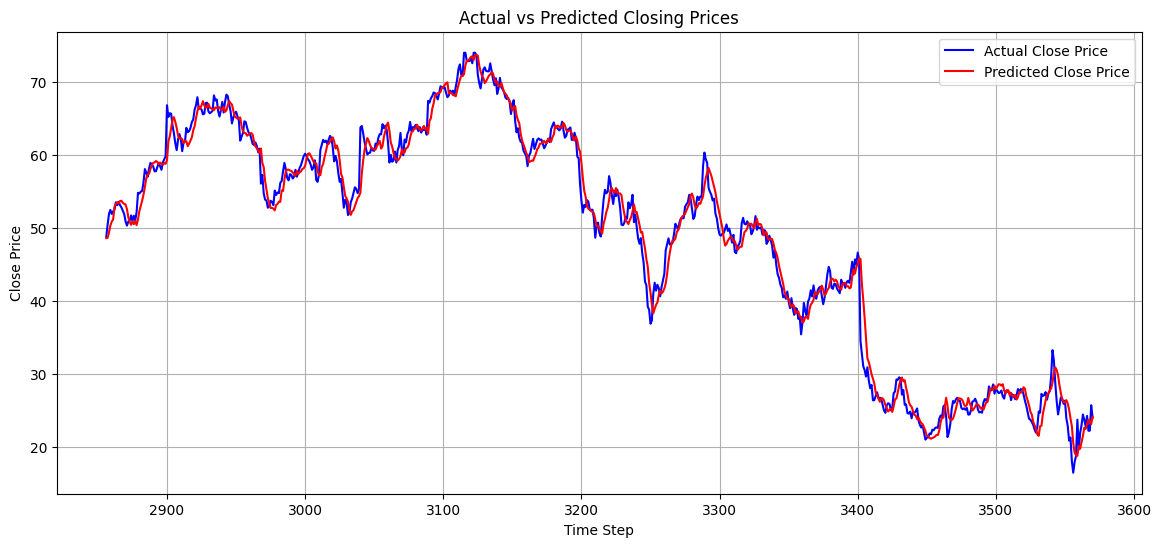

In [41]:
# 📊 8. Visualize Actual vs Predicted
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test.values, label='Actual Close Price', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Close Price', color='red')
plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Time Step')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()